# 🚨 Storytelling with Data: ชุดข้อมูลเหตุความรุนแรงในครอบครัว (Domestic Violence in Thailand)

**🎯 เป้าหมาย:** นำเสนอกระบวนการ Data Storytelling ตั้งแต่ต้นจนจบ (ตั้งแต่การโหลดข้อมูล → EDA → ทำความสะอาด → หา Insight → เตรียม Dashboard) เพื่อตอบคำถามสำคัญ 3 ประการของการแข่งขัน (ใครเสี่ยงที่สุด? เกิดที่ไหนเมื่อไหร่? อะไรคือสัญญาณเตือน?) และนำเสนอข้อเสนอแนะเชิงนโยบาย (Actionable Policy)

**🔗 Link Colab:** https://colab.research.google.com/drive/1hiPir_kQ5GD4zHRCfMqk46Effy6RIq2X?usp=sharing

**🔗 Link Dataset:** https://www.thackle.or.th/th/dataset/84

### 📑 ขั้นตอนการวิเคราะห์ (Table of Contents)
* **1️⃣ Setup, Load Data & EDA:** การเตรียมข้อมูล, ตรวจสอบคุณภาพ (Data Quality Check) และสแกนภาพรวม
* **2️⃣ Insight Discovery (ข้อ 1):** ใครเสี่ยงที่สุด? (Who is at risk?)
* **3️⃣ Insight Discovery (ข้อ 2):** เกิดที่ไหน เมื่อไหร่? (Where & When?)
* **4️⃣ Insight Discovery (ข้อ 3):** อะไรคือสัญญาณเตือน? (What triggers violence?)
* **5️⃣ Dashboard & Executive Summary:** ขมวดปมผลลัพธ์ลงใน Interactive Dashboard พร้อมบทสรุปผู้บริหาร

**📦 ข้อมูล:** ชุดข้อมูลเหตุความรุนแรงในครอบครัว (แบ่งเป็น 3 ไฟล์: ข้อมูลการแจ้งเหตุ, ข้อมูลผู้กระทำ, ข้อมูลผู้ถูกกระทำ)
**🗂️ แหล่งที่มา:** กรมกิจการสตรีและสถาบันครอบครัว (ผ่านแพลตฟอร์มการแข่งขัน THackle DataViz Challenge)

---

### 🤔 ก่อนเริ่ม: Data Storytelling คืออะไร และทำไมถึงสำคัญ?
การวิเคราะห์ข้อมูลมิได้จำกัดอยู่เพียงการเขียนโค้ดและสร้างภาพข้อมูล หากแต่ครอบคลุมถึงการแปลความหมายเชิงลึก เพื่อเชื่อมโยงตัวเลขกับบริบทที่ผู้รับสารเข้าใจได้ และนำไปสู่การตัดสินใจได้อย่างมีประสิทธิผล

```
Raw Data → Analysis → Insight → Story → Decision
    ↑                                      ↑
หลายคนทำได้                          แต่น้อยคนทำถึงตรงนี้
```

**Data Storytelling ที่ดีต้องมี 3 องค์ประกอบ:**
* 📊 **Data** — ตัวเลขที่ผ่านการทำความสะอาด (Cleaning) ถูกต้อง และเชื่อถือได้
* 🎨 **Visualization** — กราฟที่สื่อความหมายได้ชัดเจน หักล้างความเชื่อเดิม (Myth Buster)
* 📖 **Narrative** — เรื่องราวที่เชื่อมทุกอย่างเข้าด้วยกัน เพื่อนำไปสู่การกำหนดนโยบาย (Actionable Policy)

---

## 1️⃣ Setup, Load Data & Exploratory Data Analysis (EDA)
ในขั้นตอนแรก เราจะทำการนำเข้าเครื่องมือ (Libraries) โหลดชุดข้อมูล ตรวจสอบคุณภาพข้อมูล (Data Quality) ทำความสะอาด (Cleaning) และสแกนดูภาพรวม (Distribution) เพื่อปูทางไปสู่การตั้งคำถามเชิงลึกครับ

In [ ]:
# 1. ติดตั้งฟอนต์ภาษาไทยและ Import Libraries

# ดาวน์โหลดไฟล์ฟอนต์ TH Sarabun New จาก GitHub มาไว้ในระบบ (มักใช้ใน Google Colab)
# -q ย่อมาจาก quiet เพื่อไม่ให้แสดงข้อความรกหน้าจอขณะดาวน์โหลด
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf

# นำเข้าไลบรารี Pandas สำหรับจัดการข้อมูลแบบตาราง (Dataframe) โดยตั้งชื่อย่อว่า pd
import pandas as pd

# นำเข้าไลบรารี NumPy สำหรับการคำนวณตัวเลขและจัดการอาร์เรย์ โดยตั้งชื่อย่อว่า np
import numpy as np

# นำเข้าไลบรารีหลัก Matplotlib สำหรับการตั้งค่าเกี่ยวกับกราฟ
import matplotlib as mpl

# นำเข้าโมดูล pyplot จาก Matplotlib สำหรับสร้างและแสดงกราฟ โดยตั้งชื่อย่อว่า plt
import matplotlib.pyplot as plt

# นำเข้าไลบรารี Seaborn สำหรับสร้างกราฟสถิติให้สวยงามและง่ายขึ้น โดยตั้งชื่อย่อว่า sns
import seaborn as sns

# นำเข้าไลบรารี warnings สำหรับจัดการข้อความแจ้งเตือนของ Python
import warnings

# ตั้งค่าให้ละเว้น (ignore) ข้อความแจ้งเตือนสีแดงๆ ที่ไม่ส่งผลต่อการทำงาน เพื่อให้ผลลัพธ์ดูสะอาดตา
warnings.filterwarnings('ignore')

# ตั้งค่าฟอนต์ภาษาไทยให้ Matplotlib

# นำไฟล์ฟอนต์ที่ดาวน์โหลดไว้ข้างต้น เข้าสู่ระบบจัดการฟอนต์ของเครื่อง/Colab
mpl.font_manager.fontManager.addfont('thsarabunnew-webfont.ttf')

# ตั้งค่าเริ่มต้นของกราฟ (rc = runtime configuration) ให้ใช้ฟอนต์ 'TH Sarabun New' และมีขนาดตัวอักษร 14
mpl.rc('font', family='TH Sarabun New', size=14)

# ตั้งค่า Theme ของกราฟ Seaborn ให้มีพื้นหลังเป็นตารางสีขาว (whitegrid) และบังคับใช้ฟอนต์ภาษาไทยด้วย
sns.set_theme(style="whitegrid", font="TH Sarabun New")

# กำหนดความละเอียดของรูปภาพกราฟ (Dots Per Inch) ให้เป็น 100 เพื่อให้ภาพคมชัดเวลาแสดงผล
plt.rcParams['figure.dpi'] = 100

# 2. โหลดข้อมูล (การใช้ Try-Except เพื่อป้องกันโปรแกรมพังกรณีไฟล์มีการเข้ารหัสต่างกัน)

try:
    # --- เริ่มต้นทดลองโหลดข้อมูลด้วยมาตรฐาน UTF-8 ---

    # อ่านไฟล์ CSV แจ้งเหตุ ลงในตัวแปร df_incident โดยระบุการเข้ารหัส 'utf-8-sig' (รองรับภาษาไทยยุคใหม่ ป้องกันสระ/วรรณยุกต์พัง)
    df_incident = pd.read_csv('ข้อมูลการแจ้งเหตุความรุนแรงในครอบครัว.csv', encoding='utf-8-sig')

    # อ่านไฟล์ CSV ผู้กระทำ ลงในตัวแปร df_perp
    df_perp = pd.read_csv('ข้อมูลผู้กระทำความรุนแรงในครอบครัว.csv', encoding='utf-8-sig')

    # อ่านไฟล์ CSV ผู้ถูกกระทำ ลงในตัวแปร df_victim
    df_victim = pd.read_csv('ข้อมูลผู้ถูกกระทำความรุนแรงในครอบครัว.csv', encoding='utf-8-sig')

    # หากบรรทัดข้างบนทำงานผ่านทั้งหมด (ไม่ Error) ให้ปริ้นข้อความนี้
    print("✅ โหลดข้อมูลสำเร็จ!")

except Exception as e:
    # --- หากบล็อก try ด้านบน Error (เช่น ไฟล์เซฟมาเป็นภาษาไทยแบบเก่า) โปรแกรมจะข้ามมาทำส่วนนี้แทน ---

    # ลองอ่านไฟล์ CSV ใหม่อีกครั้ง แต่เปลี่ยนการเข้ารหัสเป็น 'tis-620' (มาตรฐานภาษาไทยแบบเก่า มักพบในไฟล์ที่ Export จาก Excel รุ่นเก่า)
    df_incident = pd.read_csv('ข้อมูลการแจ้งเหตุความรุนแรงในครอบครัว.csv', encoding='tis-620')

    df_perp = pd.read_csv('ข้อมูลผู้กระทำความรุนแรงในครอบครัว.csv', encoding='tis-620')

    df_victim = pd.read_csv('ข้อมูลผู้ถูกกระทำความรุนแรงในครอบครัว.csv', encoding='tis-620')

    # หากโหลดด้วย TIS-620 สำเร็จ ให้ปริ้นข้อความนี้เพื่อแจ้งให้ผู้ใช้ทราบว่าใช้ Encoding ไหนอยู่
    print("✅ โหลดข้อมูลสำเร็จ! (ใช้ TIS-620)")

✅ โหลดข้อมูลสำเร็จ!


In [ ]:
# 3. ตรวจสอบคุณภาพข้อมูล (Data Quality Check)

# สร้างตัวแปรประเภท Dictionary ชื่อ 'datasets' เพื่อจับกลุ่มตารางทั้ง 3 ชุดไว้ด้วยกัน
# โดยฝั่งซ้าย (Key) คือ "ข้อความที่เราอยากให้ปริ้นออกมาโชว์"
# ส่วนฝั่งขวา (Value) คือ "ตัวแปร DataFrame ที่เราโหลดข้อมูลเก็บไว้"
# การทำแบบนี้จะช่วยให้เราใช้ Loop วนเช็คข้อมูลทีเดียวจบ ไม่ต้องเขียนโค้ดเช็คทีละตารางให้ซ้ำซ้อน
datasets = {
    'การแจ้งเหตุ (Incident)': df_incident,
    'ผู้กระทำ (Perpetrator)': df_perp,
    'ผู้ถูกกระทำ (Victim)': df_victim
}

# ปริ้นเครื่องหมายเท่ากับ (=) ติดต่อกัน 65 ตัว เพื่อสร้างเส้นคั่นตารางให้สวยงามและเป็นระเบียบ
print("="*65)

# ปริ้นข้อความหัวข้อของรายงาน
print("🔍 รายงานการตรวจสอบคุณภาพข้อมูลเบื้องต้น (Data Quality Check)")

# ปริ้นเส้นคั่นอีกบรรทัด ปิดท้ายหัวข้อ
print("="*65)

# สร้าง For Loop เพื่อวนอ่านข้อมูลจาก Dictionary 'datasets' ทีละคู่
# .items() จะโยนค่าออกมา 2 อย่างพร้อมกัน คือ 'name' (รับข้อความชื่อตาราง) และ 'df' (รับตัว DataFrame)
for name, df in datasets.items():

    # คำสั่ง df.shape จะบอกขนาดของตาราง โดยส่งค่าออกมา 2 ตัว
    # เราจึงเอาตัวแปร rows มารับค่า "จำนวนแถว" และ cols มารับค่า "จำนวนคอลัมน์"
    rows, cols = df.shape

    # คำสั่ง df.duplicated() จะตรวจสอบว่ามีข้อมูลบรรทัดไหนหน้าตาเหมือนกันเป๊ะๆ (ซ้ำซ้อน) หรือไม่
    # คำสั่ง .sum() จะทำการนับรวมจำนวนบรรทัดที่ซ้ำกันทั้งหมด แล้วนำไปเก็บในตัวแปร dupes
    dupes = df.duplicated().sum()

    # คำสั่ง df.isnull() จะเช็คทุกๆ ช่องในตารางว่ามีช่องไหนเป็นค่าว่าง (NaN/Null) หรือไม่
    # .sum() ตัวแรก จะนับรวมค่าว่างแยกตามคอลัมน์
    # .sum() ตัวที่สอง จะเอาค่าว่างของทุกคอลัมน์มารวมกันเป็นตัวเลขเดียว (ค่าว่างทั้งหมดทั้งตาราง)
    nulls = df.isnull().sum().sum()

    # ปริ้นชื่อตาราง (f-string ช่วยให้เราแทรกตัวแปร name ลงในข้อความได้เลยผ่านปีกกา {})
    print(f"📂 {name}")

    # ปริ้นจำนวนแถวและคอลัมน์ (การใส่ :, หลัง rows คือการสั่งให้ใส่ลูกน้ำหลักพัน เช่น 1,000 แถว)
    print(f"   - ขนาดข้อมูล   : {rows:,} แถว | {cols} คอลัมน์")

    # ปริ้นจำนวนแถวที่ซ้ำซ้อนกัน
    print(f"   - แถวซ้ำ (Dup) : {dupes:,} แถว")

    # ปริ้นจำนวนช่องที่เป็นค่าว่าง
    print(f"   - ค่าว่าง (Null): {nulls:,} จุด")

    # ปริ้นเครื่องหมายขีด (-) ติดต่อกัน 65 ตัว เพื่อสร้างเส้นคั่นแบ่งระหว่างตารางแต่ละชุดให้อ่านง่าย
    print("-" * 65)

🔍 รายงานการตรวจสอบคุณภาพข้อมูลเบื้องต้น (Data Quality Check)
📂 การแจ้งเหตุ (Incident)
   - ขนาดข้อมูล   : 877 แถว | 11 คอลัมน์
   - แถวซ้ำ (Dup) : 16 แถว
   - ค่าว่าง (Null): 0 จุด
-----------------------------------------------------------------
📂 ผู้กระทำ (Perpetrator)
   - ขนาดข้อมูล   : 564 แถว | 19 คอลัมน์
   - แถวซ้ำ (Dup) : 11 แถว
   - ค่าว่าง (Null): 0 จุด
-----------------------------------------------------------------
📂 ผู้ถูกกระทำ (Victim)
   - ขนาดข้อมูล   : 597 แถว | 20 คอลัมน์
   - แถวซ้ำ (Dup) : 10 แถว
   - ค่าว่าง (Null): 0 จุด
-----------------------------------------------------------------


### 🧹 Cleaning Log (บันทึกการทำความสะอาดข้อมูล)
จากการตรวจสอบเบื้องต้น (EDA) พบประเด็นด้านคุณภาพข้อมูลที่จะต้องจัดการก่อนวิเคราะห์ ดังนี้:
1. **Duplicates:** ข้อมูลทั้ง 3 ตารางมีแถวซ้ำ (Duplicates) จำนวนหนึ่ง (แจ้งเหตุซ้ำ 16 แถว, ผู้กระทำซ้ำ 11 แถว, ผู้ถูกกระทำซ้ำ 10 แถว) ซึ่งคาดว่าเกิดจากการบันทึกซ้ำซ้อนในระบบฐานข้อมูลต้นทาง
   * *Action:* ทำการลบแถวซ้ำออก (Drop Duplicates) เพื่อให้ตัวเลขทางสถิติไม่บิดเบือน
2. **Missing Values & Garbage Data:** แม้ระบบจะไม่มีค่า Null ทางเทคนิค (0 จุด) แต่พบความไม่เป็นระเบียบในคอลัมน์ `Relation Type` (เช่น "อื่นๆ แฟน", เว้นวรรคเกิน) และคอลัมน์เพศมีค่า "ไม่ระบุ"
   * *Action:* กรองเฉพาะเพศชาย/หญิง ตัดช่องว่าง (Strip) และทำ Grouping หมวดหมู่ความสัมพันธ์ใหม่ให้สะอาดขึ้น

In [ ]:
# 4. ทำความสะอาดข้อมูลตาม Cleaning Log

# ==========================================
# Action 1: Drop Duplicates (ลบข้อมูลที่ซ้ำซ้อน)
# ==========================================

# คำสั่ง .drop_duplicates() จะทำการลบแถวที่มีข้อมูลเหมือนกันทุกตัวอักษรออกไป (เหลือไว้แค่แถวเดียว)
# คำสั่ง .copy() เป็นการสั่งให้ Pandas สร้างตารางใหม่แยกออกมาเลย เพื่อป้องกัน Error (SettingWithCopyWarning) เวลาเราไปแก้ไขข้อมูลในภายหลัง
df_inc_c = df_incident.drop_duplicates().copy()
df_perp_c = df_perp.drop_duplicates().copy()
df_vic_c = df_victim.drop_duplicates().copy()

# พิมพ์แจ้งเตือนว่าการลบข้อมูลเสร็จสิ้น
print(f"✅ ลบข้อมูลซ้ำเรียบร้อย:")

# คำสั่ง len() ใช้สำหรับนับจำนวนแถวในตาราง
# บรรทัดนี้จะปริ้นเปรียบเทียบให้ดูว่า ตารางเก่า (ก่อนลบ) มีกี่แถว และตารางใหม่ที่ลงท้ายด้วย _c (หลังลบ) เหลือคลีนๆ กี่แถว
print(f"   - แจ้งเหตุ: ลดลงจาก {len(df_incident)} เหลือ {len(df_inc_c)} แถว")
print(f"   - ผู้กระทำ: ลดลงจาก {len(df_perp)} เหลือ {len(df_perp_c)} แถว")
print(f"   - เหยื่อ  : ลดลงจาก {len(df_victim)} เหลือ {len(df_vic_c)} แถว\n")

# ==========================================
# Action 2: Clean คอลัมน์เพศ และจัดการ Garbage String ในคอลัมน์ Relation
# ==========================================

# คำสั่ง .isin() ใช้เช็คว่าข้อมูลในคอลัมน์ 'Gender' ตรงกับลิสต์ ['ชาย', 'หญิง'] หรือไม่
# ถ้าตรงจะเก็บไว้ ถ้าเป็นค่าขยะ (เช่น 'ไม่ระบุเพศ') โค้ดบรรทัดนี้จะกรองทิ้งออกไปจากตารางทันที
df_perp_c = df_perp_c[df_perp_c['Gender'].isin(['ชาย', 'หญิง'])]
df_vic_c = df_vic_c[df_vic_c['Gender'].isin(['ชาย', 'หญิง'])]

# คำสั่ง .str.strip() ใช้ตัด "ช่องว่าง (Spacebar)" ที่อาจเผลอพิมพ์ติดมาทั้งด้านหน้าและด้านหลังข้อความ
# เช่น เปลี่ยน " บิดา " ให้กลายเป็น "บิดา" เพื่อให้ระบบมองว่าเป็นคำเดียวกัน
df_vic_c['Relation Type'] = df_vic_c['Relation Type'].str.strip()

# สร้างตัวแปร Dictionary ชื่อ relation_map เพื่อทำ "Data Grouping" (จัดกลุ่มข้อมูล)
# หลักการคือ "คำเก่าฝั่งซ้าย (Key) : คำใหม่ฝั่งขวา (Value)"
# สาเหตุที่ต้องทำเพราะในระบบคนกรอกข้อมูลมาสะเปะสะปะมาก เช่น มีทั้ง 'อื่นๆ แฟน', 'อื่นๆ ภรรยา' เราจึงต้องจับมัดรวมกันให้เป็นหมวดใหญ่ๆ เช่น 'คู่ครอง/คนรัก'
relation_map = {
    'คู่ชีวิต,สามี': 'คู่ครอง/คนรัก', 'คู่ชีวิต,ภรรยา': 'คู่ครอง/คนรัก',
    'อื่นๆ แฟน': 'คู่ครอง/คนรัก', 'อื่นๆ สามี': 'คู่ครอง/คนรัก', 'อื่นๆ ภรรยา': 'คู่ครอง/คนรัก',
    'อื่นๆ ภริยาไม่ชอบด้วยกฎหมาย': 'คู่ครอง/คนรัก', 'อื่นๆ แฟนใหม่': 'คู่ครอง/คนรัก',
    'คู่ชีวิต,อดีตสามี': 'อดีตคู่ครอง', 'คู่ชีวิต,อดีตภรรยา': 'อดีตคู่ครอง',
    'อื่นๆ อดีตสามี': 'อดีตคู่ครอง', 'อื่นๆ อดีตภรรยา': 'อดีตคู่ครอง',
    'อื่นๆ อดีตแฟน': 'อดีตคู่ครอง', 'อื่นๆ สามีเก่า': 'อดีตคู่ครอง',
    'บิดา': 'พ่อ/แม่/ผู้ปกครอง', 'มารดา': 'พ่อ/แม่/ผู้ปกครอง',
    'พ่อเลี้ยง': 'พ่อ/แม่/ผู้ปกครอง', 'แม่เลี้ยง': 'พ่อ/แม่/ผู้ปกครอง',
    'ผู้ปกครอง': 'พ่อ/แม่/ผู้ปกครอง', 'อื่นๆ บิดา': 'พ่อ/แม่/ผู้ปกครอง',
    'บุตร': 'บุตร', 'ลูกเลี้ยง': 'บุตร', 'บุตรบุญธรรม': 'บุตร',
    'พี่น้อง/ลูกพี่ลูกน้อง': 'ญาติพี่น้อง', 'หลาน': 'ญาติพี่น้อง', 'ลูกเขย': 'ญาติพี่น้อง', 'ลูกสะใภ้': 'ญาติพี่น้อง',
    'อื่นๆ น้องสาวต่างบิดา': 'ญาติพี่น้อง', 'อื่นๆ อดีตพี่เขย': 'ญาติพี่น้อง', 'อื่นๆ พี่สาวของอดีตคนรักผู้กระทำความรุนแรง': 'ญาติพี่น้อง',
    'ตา': 'ญาติผู้ใหญ่', 'ยาย': 'ญาติผู้ใหญ่', 'ย่า': 'ญาติผู้ใหญ่', 'ปู่': 'ญาติผู้ใหญ่',
    'ลุง': 'ญาติผู้ใหญ่', 'ป้า': 'ญาติผู้ใหญ่', 'น้า': 'ญาติผู้ใหญ่',
    'อื่นๆ ตาเลี้ยง': 'ญาติผู้ใหญ่', 'อื่นๆ มารดาสามี': 'ญาติผู้ใหญ่', 'อื่นๆ พ่อตา': 'ญาติผู้ใหญ่',
    'อื่นๆ เพื่อนบ้าน': 'บุคคลภายนอก', 'อื่นๆ คนรู้จัก': 'บุคคลภายนอก',
    'อื่นๆ คนแปลกหน้า': 'บุคคลภายนอก', 'อื่นๆ บุคคลนอกครอบครัว': 'บุคคลภายนอก',
    'อื่นๆ นักเรียน': 'บุคคลภายนอก', 'อื่นๆ เพื่อนร่วมชั้นเรียน': 'บุคคลภายนอก',
    'อื่นๆ ไม่มี': 'ไม่ระบุ', ' คู่ชีวิต,อดีตภรรยา': 'อดีตคู่ครอง'
}

# บรรทัดนี้คือพระเอกของการจัดกลุ่ม:
# 1. .map(relation_map) จะเอาคำศัพท์ในตารางไปเทียบกับ Dictionary ถ้าเจอคำฝั่งซ้าย มันจะแปลงร่างเป็นคำฝั่งขวาทันที
# 2. .fillna(df_vic_c['Relation Type']) คือ "ตาข่ายนิรภัย" เผื่อมีคำไหนในตารางที่ไม่ได้อยู่ใน Dictionary ค่ามันจะกลายเป็น Null (ค่าว่าง) เราจึงสั่งว่าถ้าเป็นค่าว่าง ให้ดึงคำเดิมมาอุดไว้เลย
# 3. นำผลลัพธ์ทั้งหมดไปสร้างเป็นคอลัมน์ใหม่ที่สะอาดเอี่ยมชื่อ 'Relation_Group'
df_vic_c['Relation_Group'] = df_vic_c['Relation Type'].map(relation_map).fillna(df_vic_c['Relation Type'])

# ปริ้นข้อความว่าทำความสะอาดสำเร็จ
print("✅ ทำความสะอาด Garbage Data และจัดกลุ่มความสัมพันธ์เรียบร้อย!")

✅ ลบข้อมูลซ้ำเรียบร้อย:
   - แจ้งเหตุ: ลดลงจาก 877 เหลือ 861 แถว
   - ผู้กระทำ: ลดลงจาก 564 เหลือ 553 แถว
   - เหยื่อ  : ลดลงจาก 597 เหลือ 587 แถว

✅ ทำความสะอาด Garbage Data และจัดกลุ่มความสัมพันธ์เรียบร้อย!


🎯 KPI: อัตราการระบุตัวผู้ก่อเหตุได้ = 64.1%
⚠️ มีเหตุการณ์แจ้งเข้ามา 861 ครั้ง แต่ระบุคนทำได้เพียง 552 คน (หายไป 35.9%)


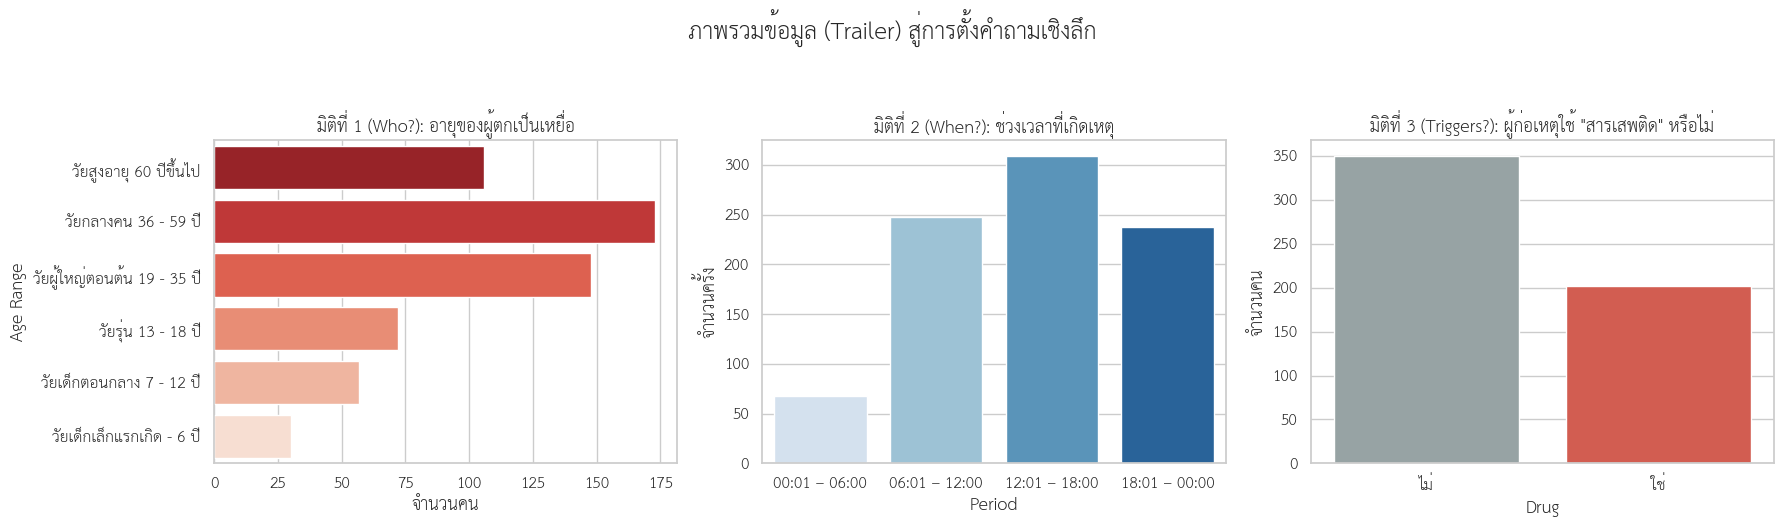

In [ ]:
# 5. การสร้าง KPI และวิเคราะห์การกระจายตัว (Distribution Analysis)

# ====================================================
# 📌 KPI: อัตราการระบุตัวผู้กระทำความผิด (Identification Rate)
# ====================================================

# นับจำนวนเหตุการณ์ความรุนแรงทั้งหมดที่ได้รับแจ้ง (จำนวนแถวของตารางแจ้งเหตุ)
total_incidents = len(df_inc_c)

# นับจำนวนผู้ก่อเหตุที่สามารถระบุตัวตนและเก็บข้อมูลได้ (จำนวนแถวของตารางผู้กระทำ)
total_perps = len(df_perp_c)

# คำนวณร้อยละ (KPI) โดยเอาจำนวนผู้ก่อเหตุ ตั้งหารด้วย จำนวนเหตุการณ์ แล้วคูณ 100
identification_rate = (total_perps / total_incidents) * 100

# พิมพ์เส้นคั่นและสรุปผลตัวเลข KPI ออกมาให้ดูโดดเด่น
print("="*65)
print(f"🎯 KPI: อัตราการระบุตัวผู้ก่อเหตุได้ = {identification_rate:.1f}%")

# พิมพ์ข้อความเตือน (⚠️) เพื่อชี้ให้เห็น "ช่องโหว่ (Data Gap)" ว่ามีเคสที่หาคนทำผิดไม่ได้ถึงเกือบ 36%
print(f"⚠️ มีเหตุการณ์แจ้งเข้ามา {total_incidents} ครั้ง แต่ระบุคนทำได้เพียง {total_perps} คน (หายไป {100-identification_rate:.1f}%)")
print("="*65)

# ====================================================
# 📌 Distribution: สแกนข้อมูล 3 มิติ ปูทางสู่โจทย์ 3 ข้อ
# ====================================================

# สร้างหน้ากระดาษวาดกราฟ (Canvas) 1 แถว 3 คอลัมน์ (เพื่อวาง 3 กราฟเรียงกัน)
# กำหนดขนาดหน้ากระดาษ (figsize) เป็น กว้าง 18 นิ้ว สูง 5 นิ้ว
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ----------------------------------------------------
# กราฟที่ 1: มิติที่ 1 (Who?): ช่วงอายุของผู้ถูกกระทำ
# ----------------------------------------------------
# สร้าง List เพื่อ "ล็อกลำดับ" ของช่วงอายุให้เรียงจากเด็กไปหาคนแก่ (ถ้าไม่ทำ กราฟจะเรียงมั่วตามตัวอักษร)
age_order = [
    'วัยเด็กเล็กแรกเกิด - 6 ปี', 'วัยเด็กตอนกลาง 7 - 12 ปี',
    'วัยรุ่น 13 - 18 ปี', 'วัยผู้ใหญ่ตอนต้น 19 - 35 ปี',
    'วัยกลางคน 36 - 59 ปี', 'วัยสูงอายุ 60 ปีขึ้นไป'
]

# นับจำนวนเหยื่อแยกตามช่วงอายุ (.value_counts())
# และบังคับเรียงลำดับตาม age_order แบบย้อนกลับ [::-1] เพื่อให้กราฟแท่งแนวนอนโชว์ผู้ใหญ่อยู่บน เด็กอยู่ล่าง
age_dist = df_vic_c['Age Range'].value_counts().reindex(age_order[::-1]).fillna(0)

# วาดกราฟแท่ง (Barplot) ลงในกรอบที่ 1 (ax=axes[0]) โดยใช้โทนสีแดง (Reds_r) เพื่อสื่อถึงผู้รับเคราะห์
sns.barplot(y=age_dist.index, x=age_dist.values, ax=axes[0], palette='Reds_r')
axes[0].set_title('มิติที่ 1 (Who?): อายุของผู้ตกเป็นเหยื่อ', fontweight='bold') # ตั้งชื่องาน
axes[0].set_xlabel('จำนวนคน') # ตั้งชื่อแกน X

# ----------------------------------------------------
# กราฟที่ 2: มิติที่ 2 (When?): ช่วงเวลาที่เกิดเหตุ
# ----------------------------------------------------
# สร้าง List เพื่อล็อกลำดับช่วงเวลาให้ถูกต้อง (เช้าไปดึก)
period_order = ['00:01 – 06:00', '06:01 – 12:00', '12:01 – 18:00', '18:01 – 00:00']

# นับจำนวนเหตุการณ์แยกตามช่วงเวลา
period_dist = df_inc_c['Period'].value_counts().reindex(period_order).fillna(0)

# วาดกราฟแท่ง ลงในกรอบที่ 2 (ax=axes[1]) ใช้โทนสีฟ้า (Blues)
sns.barplot(x=period_dist.index, y=period_dist.values, ax=axes[1], palette='Blues')
axes[1].set_title('มิติที่ 2 (When?): ช่วงเวลาที่เกิดเหตุ', fontweight='bold')
axes[1].set_ylabel('จำนวนครั้ง') # ตั้งชื่อแกน Y

# ----------------------------------------------------
# กราฟที่ 3: มิติที่ 3 (What Triggers?): ผู้ก่อเหตุกับสารเสพติด
# ----------------------------------------------------
# นับจำนวนผู้ก่อเหตุว่ามีประวัติใช้ "ยาเสพติด" (ใช่ / ไม่ใช่)
drug_dist = df_perp_c['Drug'].value_counts()

# วาดกราฟแท่ง ลงในกรอบที่ 3 (ax=axes[2])
# ตั้งค่าสีเจาะจง: สีเทา (#95a5a6) สำหรับ "ไม่ใช่" และสีแดง (#e74c3c) สำหรับ "ใช่" เพื่อดึงสายตากรรมการ
sns.barplot(x=drug_dist.index, y=drug_dist.values, ax=axes[2], palette=['#95a5a6', '#e74c3c'])
axes[2].set_title('มิติที่ 3 (Triggers?): ผู้ก่อเหตุใช้ "สารเสพติด" หรือไม่', fontweight='bold')
axes[2].set_ylabel('จำนวนคน')

# ----------------------------------------------------
# การตกแต่งภาพรวม
# ----------------------------------------------------
# ตั้งชื่อหัวข้อใหญ่ (Super Title) คลุมทั้ง 3 กราฟ
plt.suptitle('ภาพรวมข้อมูล (Trailer) สู่การตั้งคำถามเชิงลึก', fontsize=16, fontweight='bold', y=1.05)

# จัดระเบียบระยะห่างระหว่างกราฟทั้ง 3 ตัวไม่ให้ตัวหนังสือทับซ้อนกัน
plt.tight_layout()

# สั่งให้แสดงผลกราฟขึ้นมาบนหน้าจอ
plt.show()

### 🔗 จากข้อมูลเบื้องต้น สู่การตั้งคำถามเชิงลึก (Next Steps)
จากการทำ EDA และสแกน Distribution เบื้องต้น เราพบสถิติที่น่าสนใจนำไปสู่การวิเคราะห์ DataViz ขั้นสูงเพื่อตอบโจทย์การแข่งขัน 3 ประการ ดังนี้:

* 👥 **ข้อ 1 — ใครเสี่ยงที่สุด? (Who is at risk?):** จากกราฟมิติที่ 1 เหยื่อกระจุกตัวในวัยผู้ใหญ่ เราจะนำไปสร้างแผนภาพเปรียบเทียบโครงสร้าง "ผู้กระทำ vs ผู้ถูกกระทำ" ในภาพเดียว เพื่อดูว่ารูปแบบความเสี่ยงของทั้งสองกลุ่มเหมือนหรือต่างกันอย่างไร
* 📍⏰ **ข้อ 2 — เกิดที่ไหน เมื่อไหร่? (Where & When?):** จากกราฟมิติที่ 2 การเกิดเหตุกระจายไปหลายช่วงเวลา เราจะนำไปเจาะลึกร่วมกับมิติของ "พื้นที่ (Province)" เพื่อหาพิกัด Hotspot ที่แท้จริง
* ⚠️ **ข้อ 3 — อะไรคือสัญญาณเตือน? (What triggers violence?):** จากกราฟมิติที่ 3 ที่พบว่ามีผู้ก่อเหตุพัวพันสารเสพติด เราจะนำตัวแปรเสี่ยงทั้งหมด (เช่น สุรา, หึงหวง, เครียด) มาเรียงลำดับความสำคัญ เพื่อหาว่าปัจจัยใดควรถูกนำไปออกแบบมาตรการป้องกันก่อนเป็นอันดับแรก

## 2️⃣ Insight Discovery: ข้อ 1 — ใครเสี่ยงที่สุด? (Who is at risk?)
**🎯 โจทย์:** กลุ่มอายุใด เพศใด มีความเสี่ยงสูงที่สุดในแต่ละบทบาท และรูปแบบความเสี่ยงของผู้กระทำและผู้ถูกกระทำมีความแตกต่างกันอย่างไร?

**💡 กลยุทธ์การวิเคราะห์ (Level 4):**
เพื่อให้สามารถเปรียบเทียบโครงสร้างของทั้งสองกลุ่มได้ในภาพเดียว เราจะทำการรวมข้อมูล (Data Merging) ระหว่างผู้กระทำและผู้ถูกกระทำให้อยู่ในรูปแบบ **Tidy Data** โดยเพิ่มคอลัมน์ `Role` (บทบาท) จากนั้นใช้กราฟแบบ **Facet Grouped Bar Chart** เพื่อแสดงความสัมพันธ์แบบ 3 มิติ (บทบาท × ช่วงอายุ × เพศ)

In [ ]:
# 1. จัดเตรียม Data สำหรับเปรียบเทียบ (Tidy Data Transformation)

# ====================================================
# การสร้างคอลัมน์เพื่อแบ่งแยกกลุ่ม
# ====================================================
# สร้างคอลัมน์ใหม่ชื่อ 'Role' (บทบาท) ให้กับตารางผู้กระทำ (`df_perp_c`)
# แล้วเติมคำว่า 'ผู้กระทำ' ลงไปในทุกๆ แถวของตารางนี้
df_perp_c['Role'] = 'ผู้กระทำ'

# สร้างคอลัมน์ใหม่ชื่อ 'Role' ให้กับตารางผู้ถูกกระทำ (`df_vic_c`)
# แล้วเติมคำว่า 'ผู้ถูกกระทำ' ลงไปในทุกๆ แถวเช่นเดียวกัน
df_vic_c['Role'] = 'ผู้ถูกกระทำ'

# ====================================================
# การเลือกคอลัมน์และการรวมตาราง (Data Merging / Concatenation)
# ====================================================
# สร้างตัวแปร List ชื่อ COMMON_COLS เพื่อเก็บ "ชื่อคอลัมน์ที่ทั้ง 2 ตารางมีเหมือนกัน"
# สาเหตุที่ต้องทำแบบนี้ เพราะถ้าเราเอาตารางมารวมกันโดยที่คอลัมน์ไม่เท่ากัน (เช่น ฝั่งนึงมีคอลัมน์ปัญหาสุขภาพ แต่อีกฝั่งไม่มี) ข้อมูลจะเกิดค่าว่าง (NaN) มหาศาล
COMMON_COLS = ['Regional', 'Province', 'District', 'Sub-District', 'Gender', 'Age Range', 'Role']

# ทำการต่อตาราง (Concatenation) ด้วยคำสั่ง pd.concat()
# โดยเอาข้อมูลผู้กระทำมาวางไว้ข้างบน และต่อท้ายด้วยข้อมูลผู้ถูกกระทำ (ต่อแบบบน-ล่าง)
# เฉพาะคอลัมน์ที่เราเลือกไว้ใน COMMON_COLS เท่านั้น
# ignore_index=True คือการสั่งให้ลบเลข Index (เลขบรรทัด) ของตารางเก่าทิ้ง แล้วรันเลขใหม่ตั้งแต่ 0 ไปจนจบ เพื่อให้ข้อมูลเป็นเนื้อเดียวกัน
df_people = pd.concat([df_perp_c[COMMON_COLS], df_vic_c[COMMON_COLS]], ignore_index=True)

# พิมพ์ข้อความยืนยันการรวมตาราง พร้อมแสดงจำนวนบรรทัดทั้งหมดของตารางใหม่
# {df_people.shape[0]:,} คือการดึงจำนวนแถวมาแสดงผล และใส่ลูกน้ำ (,) หลักพันให้อ่านง่าย
print(f'✅ รวมข้อมูลบุคคลสำเร็จ! ได้ DataFrame ขนาด {df_people.shape[0]:,} แถว')

# ====================================================
# การจัดระเบียบข้อมูลประเภท "กลุ่มอายุ" (Categorical Ordering)
# ====================================================
# สร้าง List กำหนด "ลำดับที่ถูกต้อง" ของช่วงอายุ (จากเด็กแรกเกิด ไปจนถึง ผู้สูงอายุ)
# ถ้าเราไม่ทำขั้นตอนนี้ เวลาพล็อตกราฟ คอมพิวเตอร์จะเรียงลำดับตามตัวอักษร ก-ฮ ซึ่งจะทำให้กราฟอายุสลับที่กันมั่วไปหมด
age_order = [
    'วัยเด็กเล็กแรกเกิด - 6 ปี', 'วัยเด็กตอนกลาง 7 - 12 ปี',
    'วัยรุ่น 13 - 18 ปี', 'วัยผู้ใหญ่ตอนต้น 19 - 35 ปี',
    'วัยกลางคน 36 - 59 ปี', 'วัยสูงอายุ 60 ปีขึ้นไป'
]

# แปลงชนิดข้อมูล (Data Type) ของคอลัมน์ 'Age Range' จากข้อความธรรมดา (String)
# ให้กลายเป็นหมวดหมู่ที่ถูกจัดเรียงแล้ว (Categorical Type) ด้วยคำสั่ง pd.Categorical()
# categories=age_order คือการบังคับให้ใช้ลำดับที่เราเขียนไว้ข้างบน
# ordered=True คือการตอกย้ำระบบว่า "ข้อมูลนี้มีลำดับก่อน-หลังนะ (Ordinal Data)" ไม่ใช่แค่หมวดหมู่ทั่วไป
df_people['Age Range'] = pd.Categorical(df_people['Age Range'], categories=age_order, ordered=True)

✅ รวมข้อมูลบุคคลสำเร็จ! ได้ DataFrame ขนาด 1,138 แถว


In [ ]:
# 2. สร้าง Visualization ตอบคำถาม "ใครเสี่ยงที่สุด?"

# นำเข้า Plotly Express ซึ่งเป็นเครื่องมือสร้างกราฟ Interactive ที่เขียนโค้ดสั้นและสวยงามมาก (ตั้งชื่อย่อว่า px)
import plotly.express as px

# ====================================================
# การเตรียมข้อมูลสรุป (Data Aggregation)
# ====================================================
# ก่อนจะพล็อตกราฟ เราต้องนับจำนวนคนซะก่อน
# .groupby(['Role', 'Gender', 'Age Range']) คือการจับกลุ่มข้อมูล 3 มิติพร้อมกัน (บทบาท, เพศ, ช่วงอายุ)
# .size() คือการนับว่าในแต่ละกลุ่มที่จับมา มีจำนวนกี่คน
# .reset_index(name='Count') คือการแปลงผลลัพธ์ที่นับได้ ให้กลับมาเป็นตาราง DataFrame สวยๆ โดยตั้งชื่อคอลัมน์ผลลัพธ์ว่า 'Count'
agg_df = df_people.groupby(['Role', 'Gender', 'Age Range']).size().reset_index(name='Count')

# ====================================================
# การสร้างกราฟเปรียบเทียบ (Facet Bar Chart)
# ====================================================
# px.bar() คือคำสั่งสร้างกราฟแท่ง โดยใส่ตาราง agg_df ที่เราเพิ่งนับเลขเสร็จเข้าไป
fig = px.bar(
    agg_df,
    x='Count',       # ให้แกน X แนวนอน แสดง "จำนวนคน"
    y='Age Range',   # ให้แกน Y แนวตั้ง แสดง "ช่วงอายุ"
    color='Gender',  # ให้แยกสีแท่งกราฟตาม "เพศ"

    # barmode='group' คือคำสั่งบังคับให้แท่งกราฟของ ชาย-หญิง มายืนเรียงคู่กัน (ถ้าไม่ใส่ แท่งมันจะต่อทับกันเป็นแท่งเดียว)
    barmode='group',

    # facet_col='Role' *** นี่คือคำสั่งที่แพงที่สุด! *** มันจะทำการ "ผ่า" กราฟออกเป็น 2 ฝั่งซ้าย-ขวา ตามบทบาท (ผู้กระทำ vs ผู้ถูกกระทำ) โดยอัตโนมัติ
    facet_col='Role',

    # กำหนดสีแบบเจาะจง เพื่อสื่อความหมาย (ผู้ชาย = สีกรมท่าดูดุดัน, ผู้หญิง = สีชมพูเข้ม)
    color_discrete_map={'ชาย': '#2c3e50', 'หญิง': '#e91e8c'},

    # ตั้งชื่อกราฟหลัก
    title='👥 โครงสร้างความเสี่ยง: เปรียบเทียบผู้กระทำ vs ผู้ถูกกระทำ (แยกตามช่วงอายุและเพศ)',

    # เปลี่ยนชื่อแกนภาษาอังกฤษ ให้แสดงผลเป็นภาษาไทยให้กรรมการอ่านง่ายๆ
    labels={'Count': 'จำนวนคน', 'Age Range': 'ช่วงอายุ', 'Gender': 'เพศ'},

    # กำหนดความสูงของกราฟให้พอดีกับหน้าจอ
    height=550
)

# ====================================================
# การปรับแต่งความสวยงาม (Aesthetic Tweaks - Level 4)
# ====================================================
# .update_layout() ใช้ปรับแต่งองค์ประกอบรอบๆ กราฟ
fig.update_layout(
    title=dict(font=dict(size=18), x=0.5), # ปรับขนาดฟอนต์หัวข้อ และ x=0.5 คือการจัดให้อยู่ "กึ่งกลาง"
    plot_bgcolor='white',                  # เปลี่ยนพื้นหลังกราฟให้เป็นสีขาวล้วนดูมินิมอล
    paper_bgcolor='#f8f9fa',               # เปลี่ยนสีขอบรอบนอกให้เป็นสีเทาอ่อนๆ คล้าย Dashboard

    # ย้ายกล่องคำอธิบายสี (Legend) จากที่เกะกะอยู่ด้านขวา ให้กลายเป็นแนวนอน (h) ไปแปะไว้มุมขวาบนอย่างสวยงาม
    legend=dict(title='เพศ', orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

# .update_yaxes() ปรับแต่งแกน Y
# categoryorder='array', categoryarray=age_order[::-1] คือการ "ล็อกพิกัด" ให้เรียงอายุจากคนแก่อยู่ด้านบน เด็กอยู่ด้านล่าง (ตามตัวแปร age_order ที่เราเรียงไว้ก่อนหน้านี้)
# showgrid=True, gridcolor='#ecf0f1' เปิดเส้นตารางบางๆ สีเทาอ่อน เพื่อให้สายตาลากดูตัวเลขได้ง่ายขึ้น
fig.update_yaxes(categoryorder='array', categoryarray=age_order[::-1], showgrid=True, gridcolor='#ecf0f1')

# เปิดเส้นตารางบางๆ ในแนวแกน X ด้วยเช่นกัน
fig.update_xaxes(showgrid=True, gridcolor='#ecf0f1')

# คำสั่งสุดท้าย: สั่งให้วาดกราฟ Interactive นี้โชว์ขึ้นมาบนหน้าจอ!
fig.show()

### 💡 สรุป Insight ข้อ 1 (Who is at risk?)
กราฟแสดงโครงสร้างอายุและเพศเผยให้เห็น **"ความแตกต่างเชิงโครงสร้าง (Structural Difference)"** ของความเสี่ยงระหว่าง 2 บทบาทอย่างมีนัยสำคัญ:

**1. 👨 โครงสร้าง "ผู้กระทำความรุนแรง": ผูกขาดโดยผู้ชายวัยทำงาน**
* **What:** เพศชายครองสัดส่วนผู้กระทำความผิดสูงถึงเกือบ 82% โดยมีจุดวิกฤต (Peak) อยู่ที่ **"วัยกลางคน 36-59 ปี"** * **Why:** กลุ่มอายุนี้คือวัยหัวหน้าครอบครัว ซึ่งมักเผชิญความกดดันสูงทางเศรษฐกิจ และเป็นช่วงวัยที่มีสถิติพฤติกรรมการเข้าถึงสุราและสารเสพติดสูง ซึ่งเป็นตัวเร่งให้เกิดความรุนแรงตามมา

**2. 👩 โครงสร้าง "ผู้ถูกกระทำ": ผู้หญิงรับเคราะห์ และความเปราะบางของเด็ก/คนชราเพศชาย**
* **What:** เพศหญิงคือเหยื่อหลักในแทบทุกช่วงอายุ (ประมาณ 80%) โดยกระจุกตัวมากที่สุดในวัย 19-59 ปี (ซึ่ง Match กับช่วงอายุของผู้ก่อเหตุเพศชาย บ่งชี้อย่างชัดเจนถึงปัญหาความรุนแรงระหว่างคู่สมรส)
* **Surprising Insight (จุดที่คาดไม่ถึง):** หากสังเกตในกลุ่มเหยื่อที่เป็น "เพศชาย" เราจะพบว่าส่วนใหญ่มักตกอยู่ในวัย **"เด็กเล็กถึงวัยรุ่น (0-18 ปี)"** และ **"ผู้สูงอายุ (60 ปีขึ้นไป)"** ไม่ใช่กลุ่มผู้ชายวัยทำงาน! สิ่งนี้สะท้อนว่า เพศชายจะตกเป็นเป้าความรุนแรงก็ต่อเมื่ออยู่ในสถานะที่ *อ่อนแอที่สุดทางกายภาพเท่านั้น*

✅ **Actionable Recommendation (ข้อเสนอแนะเชิงนโยบาย):**
การออกแบบมาตรการแทรกแซงความรุนแรงต้อง **แยกส่วน (Targeted approach)** ไม่สามารถใช้แบบเหมารวมได้:
* หากเป้าหมายคือการปกป้อง **"ผู้หญิง"** รัฐควรพุ่งเป้าไปที่กลไกคุ้มครอง "ความรุนแรงระหว่างคู่สมรส (Intimate Partner Violence)"
* แต่หากเป้าหมายคือการปกป้อง **"ผู้ชาย"** รัฐต้องปรับเลนส์ไปที่การเฝ้าระวังและช่วยเหลือ "เด็กและคนชรา (Child & Elder Abuse)" ผ่านโรงเรียนและหน่วยงานสาธารณสุขในชุมชน

### 💡 สรุป Insight ข้อ 1 (Who is at risk?)
กราฟแสดงโครงสร้างอายุและเพศเผยให้เห็น **"ความแตกต่างเชิงโครงสร้าง (Structural Difference)"** ของความเสี่ยงระหว่าง 2 บทบาทอย่างมีนัยสำคัญ:

**1. 👨 โครงสร้าง "ผู้กระทำความรุนแรง": ผูกขาดโดยผู้ชายวัยทำงาน**
* **What:** เพศชายครองสัดส่วนผู้กระทำความผิดสูงถึงเกือบ 82% โดยมีจุดวิกฤต (Peak) อยู่ที่ **"วัยกลางคน 36-59 ปี"** * **Why:** กลุ่มอายุนี้คือวัยหัวหน้าครอบครัว ซึ่งมักเผชิญความกดดันสูงทางเศรษฐกิจ และเป็นช่วงวัยที่มีสถิติพฤติกรรมการเข้าถึงสุราและสารเสพติดสูง ซึ่งเป็นตัวเร่งให้เกิดความรุนแรงตามมา

**2. 👩 โครงสร้าง "ผู้ถูกกระทำ": ผู้หญิงรับเคราะห์ และความเปราะบางของเด็ก/คนชราเพศชาย**
* **What:** เพศหญิงคือเหยื่อหลักในแทบทุกช่วงอายุ (ประมาณ 80%) โดยกระจุกตัวมากที่สุดในวัย 19-59 ปี (ซึ่ง Match กับช่วงอายุของผู้ก่อเหตุเพศชาย บ่งชี้อย่างชัดเจนถึงปัญหาความรุนแรงระหว่างคู่สมรส)
* **Surprising Insight (จุดที่คาดไม่ถึง):** หากสังเกตในกลุ่มเหยื่อที่เป็น "เพศชาย" เราจะพบว่าส่วนใหญ่มักตกอยู่ในวัย **"เด็กเล็กถึงวัยรุ่น (0-18 ปี)"** และ **"ผู้สูงอายุ (60 ปีขึ้นไป)"** ไม่ใช่กลุ่มผู้ชายวัยทำงาน! สิ่งนี้สะท้อนว่า เพศชายจะตกเป็นเป้าความรุนแรงก็ต่อเมื่ออยู่ในสถานะที่ *อ่อนแอที่สุดทางกายภาพเท่านั้น*

✅ **Actionable Recommendation (ข้อเสนอแนะเชิงนโยบาย):**
การออกแบบมาตรการแทรกแซงความรุนแรงต้อง **แยกส่วน (Targeted approach)** ไม่สามารถใช้แบบเหมารวมได้:
* หากเป้าหมายคือการปกป้อง **"ผู้หญิง"** รัฐควรพุ่งเป้าไปที่กลไกคุ้มครอง "ความรุนแรงระหว่างคู่สมรส (Intimate Partner Violence)"
* แต่หากเป้าหมายคือการปกป้อง **"ผู้ชาย"** รัฐต้องปรับเลนส์ไปที่การเฝ้าระวังและช่วยเหลือ "เด็กและคนชรา (Child & Elder Abuse)" ผ่านโรงเรียนและหน่วยงานสาธารณสุขในชุมชน

## 3️⃣ Insight Discovery: ข้อ 2 — เกิดที่ไหน เมื่อไหร่? (Where & When?)
**🎯 โจทย์:** รูปแบบการกระจายตัวของเหตุการณ์ความรุนแรงในครอบครัวเกิดขึ้นที่ใดบ่อยที่สุด และเกิดขึ้นในช่วงเวลาใดมากที่สุด เพื่อระบุ "จุดวิกฤต (Hotspot)"

**💡 กลยุทธ์การวิเคราะห์ (Level 4):**
ความรุนแรงไม่ใช่สิ่งที่เกิดขึ้นแบบสุ่ม (Random) เราจะวิเคราะห์ข้อมูลจากตารางการแจ้งเหตุ (`df_inc_c`) โดยใช้เทคนิค **Spatio-Temporal Analysis (การวิเคราะห์เชิงพื้นที่และเวลา)** เราจะสร้าง Dashboard ที่ประกอบด้วย:
1. **Bar Chart (ซ้าย):** จัดอันดับ Top 15 จังหวัดที่มีการรับแจ้งเหตุสูงสุด
2. **Heatmap (ขวา):** แผนภาพความร้อนข้ามมิติระหว่าง "ภูมิภาค" และ "ช่วงเวลา" เพื่อค้นหา Hotspot ที่แท้จริง และหักล้างความเชื่อ (Myth) ที่ว่าความรุนแรงมักเกิดตอนดึก

In [ ]:
# 1. จัดเตรียมข้อมูลมิติเวลาและพื้นที่

# นำเข้าเครื่องมือจาก Plotly สำหรับวาดกราฟ (go) และเครื่องมือแบ่งหน้าจอกราฟ (make_subplots)
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ====================================================
# --- จัดการข้อมูลเวลา (Temporal Data) ---
# ====================================================

# กำหนดรายชื่อช่วงเวลาแบบดั้งเดิมที่มีอยู่ในตาราง
period_order = ['00:01 – 06:00', '06:01 – 12:00', '12:01 – 18:00', '18:01 – 00:00']

# กำหนดชื่อเรียกใหม่ให้เป็นภาษาที่คนทั่วไป "อ่านแล้วเข้าใจทันที (Human-readable)"
period_labels = ['หลังเที่ยงคืน (00-06น.)', 'เช้า (06-12น.)', 'บ่าย (12-18น.)', 'หัวค่ำ-ดึก (18-00น.)']

# จับคู่คำเก่าและคำใหม่เข้าด้วยกันเป็น Dictionary ด้วยคำสั่ง dict(zip(เก่า, ใหม่))
period_map = dict(zip(period_order, period_labels))

# นำคำใหม่ไปแทนที่คำเก่าในตาราง และสร้างเป็นคอลัมน์ใหม่ชื่อ 'Period_Cat'
df_inc_c['Period_Cat'] = df_inc_c['Period'].map(period_map)

# แปลงคอลัมน์ 'Period_Cat' ให้เป็นหมวดหมู่แบบล็อกลำดับ (Categorical)
# เพื่อป้องกันไม่ให้กราฟเอาเวลาไปเรียงตามตัวอักษร (ก-ฮ) แต่วางเรียงตามลำดับเวลาจริงๆ จากเช้าไปดึก
df_inc_c['Period_Cat'] = pd.Categorical(df_inc_c['Period_Cat'], categories=period_labels, ordered=True)

# สร้างตาราง Matrix 2 มิติ สำหรับวาดแผนภาพความร้อน (Heatmap)
# .groupby(['Regional', 'Period_Cat']).size() คือการนับจำนวนเคสแยกตามภาคและเวลา
# .unstack() คือคำสั่ง "พลิก" ข้อมูลจากแนวตั้งให้กางออกเป็นแนวนอน (ตารางตารางหมากรุก)
# fill_value=0 หมายความว่า ถ้าช่องไหนไม่มีคนแจ้งเหตุเลย ให้ใส่เลข 0 แทนค่าว่าง
heatmap_data = df_inc_c.groupby(['Regional', 'Period_Cat']).size().unstack(fill_value=0)

# เรียงลำดับแถวของภูมิภาคใหม่ด้วยมือ (.loc) โดยจงใจเอา 'ภาคกลาง' ไว้ล่างสุด
# (ใน Plotly กราฟ Heatmap จะวาดจากล่างขึ้นบน การเอาภาคกลางไว้ล่างสุดแปลว่ามันจะไปโชว์อยู่แถวบนสุดของกราฟพอดีครับ)
heatmap_data = heatmap_data.loc[['ภาคใต้', 'ภาคเหนือ', 'ภาคตะวันออกเฉียงเหนือ', 'ภาคกลาง']]

# ====================================================
# --- จัดการข้อมูลพื้นที่ (Spatial Data) ---
# ====================================================

# นับจำนวนเหตุการณ์รายจังหวัด แล้วใช้คำสั่ง .nlargest(15) เพื่อ "ดึงมาเฉพาะ Top 15 จังหวัด" ที่เกิดเหตุสูงสุด
top15_prov = df_inc_c['Province'].value_counts().nlargest(15).reset_index()

# เปลี่ยนชื่อคอลัมน์ให้เรียกใช้งานง่ายขึ้น
top15_prov.columns = ['Province', 'Incident_Count']


# ====================================================
# 2. สร้าง Mini-Dashboard (Bar Chart + Heatmap)
# ====================================================

# สร้างหน้าจอกราฟแบบ 1 แถว 2 คอลัมน์ (ซ้าย-ขวา)
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['📍 Top 15 จังหวัดที่มีการแจ้งเหตุสูงสุด', '🔥 Hotspot: ภูมิภาค vs ช่วงเวลาที่เกิดเหตุ'], # ตั้งชื่อกราฟย่อย
    column_widths=[0.4, 0.6], # แบ่งพื้นที่หน้าจอ: กราฟซ้ายกินพื้นที่ 40% กราฟขวากิน 60%
    horizontal_spacing=0.1    # เว้นช่องว่างระหว่างกราฟซ้ายขวา 10% เพื่อไม่ให้ตัวหนังสือชนกัน
)

# ----------------------------------------------------
# 📊 กราฟซ้าย: Bar Chart จังหวัด
# ----------------------------------------------------
fig.add_trace(
    go.Bar(
        y=top15_prov['Province'][::-1],        # แกน Y คือชื่อจังหวัด (ใส่ [::-1] เพื่อกลับด้านให้อันดับ 1 อยู่บนสุด)
        x=top15_prov['Incident_Count'][::-1],  # แกน X คือจำนวนคน
        orientation='h',                       # สั่งให้กราฟแท่งเป็น "แนวนอน"
        marker_color='#34495e',                # ใช้สีน้ำเงินเข้มดูเป็นทางการ
        text=top15_prov['Incident_Count'][::-1], # โชว์ตัวเลขจำนวนคนบนกราฟ
        textposition='outside'                 # ดันตัวเลขให้ออกไปอยู่นอกแท่งกราฟ จะได้อ่านง่ายๆ
    ),
    row=1, col=1 # สั่งให้กราฟนี้ไปแปะอยู่ที่ แถว 1 คอลัมน์ 1 (ฝั่งซ้าย)
)

# ----------------------------------------------------
# 📊 กราฟขวา: Heatmap ภูมิภาคและเวลา
# ----------------------------------------------------
fig.add_trace(
    go.Heatmap(
        z=heatmap_data.values,      # ตัวเลขข้อมูลที่จะกำหนดระดับความเข้มของสี
        x=heatmap_data.columns,     # แกน X คือช่วงเวลา (เช้า, บ่าย, ดึก)
        y=heatmap_data.index,       # แกน Y คือภูมิภาค (ภาคกลาง, เหนือ ฯลฯ)
        colorscale='YlOrRd',        # ใช้โทนสี Yellow-Orange-Red (ยิ่งแดงยิ่งอันตราย)
        text=heatmap_data.values,   # โชว์ตัวเลขลงในช่องสี
        texttemplate="%{text} ครั้ง", # จัดรูปแบบตัวเลขให้มีคำว่า "ครั้ง" ต่อท้าย
        hoverinfo="x+y+z",          # เมื่อเอาเมาส์ชี้ ให้โชว์ข้อมูล แกนX, Y และค่า Z
        showscale=True,             # เปิดแถบสีอธิบายด้านขวา
        colorbar=dict(title="จำนวนเคส") # ตั้งชื่อให้แถบสี
    ),
    row=1, col=2 # สั่งให้กราฟนี้ไปแปะอยู่ที่ แถว 1 คอลัมน์ 2 (ฝั่งขวา)
)

# ====================================================
# 🎨 ปรับแต่งความสวยงาม (Level 4 Style)
# ====================================================
fig.update_layout(
    title=dict(text='🚨 Where & When: พิกัดและเวลาอันตรายของความรุนแรงในครอบครัว', font=dict(size=20), x=0.5), # ชื่อ Dashboard ใหญ่
    height=500,               # ความสูง 500 พิกเซล
    showlegend=False,         # ปิดกล่อง Legend (เพราะเราใช้สีอธิบายไปหมดแล้ว ไม่จำเป็นต้องมีให้รก)
    plot_bgcolor='white',     # พื้นหลังกราฟสีขาว
    paper_bgcolor='#f8f9fa'   # พื้นหลังนอกขอบกราฟสีเทาอ่อน
)

# สั่งเติมคำอธิบายแกน X ของกราฟแท่งฝั่งซ้าย (row=1, col=1) ว่าคือ "จำนวนครั้งที่รับแจ้ง"
fig.update_xaxes(title_text='จำนวนครั้งที่รับแจ้ง', row=1, col=1)

# สั่งแสดงผลกราฟทั้งก้อนนี้ขึ้นมา
fig.show()

### 💡 สรุป Insight ข้อ 2 (Where & When?)
การผสานมิติเชิงพื้นที่และเวลา (Spatio-Temporal) บน Dashboard เผยให้เห็น "จุดวิกฤต (Hotspot)" ที่หักล้างความเชื่อเดิมๆ ของสังคมอย่างสิ้นเชิง:

**1. 📍 Where (มิติเชิงพื้นที่): ความรุนแรงคือโรคระบาดของสังคมเมือง**
* **What:** **"กรุงเทพมหานคร"** ครองแชมป์พื้นที่เกิดเหตุสูงสุด ทิ้งห่างอันดับสอง (ราชบุรี) ถึงเกือบเท่าตัว และเมื่อมองในระดับภูมิภาค **"ภาคกลาง"** คือ Hotspot สีแดงเข้มที่กินสัดส่วนเกือบครึ่งหนึ่งของประเทศ
* **Why:** สะท้อนให้เห็นว่าปัญหาความรุนแรงในครอบครัวผูกติดกับ **"ความเป็นเมือง (Urbanization)"** ความแออัด และความกดดันในการดิ้นรนเอาชีวิตรอดในศูนย์กลางเศรษฐกิจ มากกว่าสังคมชนบท

**2. ⏰ When (มิติเชิงเวลา): Myth Buster (ลบล้างความเชื่อเดิม)**
* **What:** สังคมมักมีภาพจำว่าความรุนแรงหรือการเมาสุราอาละวาดมักเกิดในยามวิกาล แต่ Heatmap กลับชี้ชัดว่าช่วงเวลา Hotspot ที่มีการรับแจ้งเหตุสูงสุดคือ **"ช่วงบ่าย (12:01 - 18:00 น.)"** (กระจุกตัวแดงจัดในภาคกลาง) รองลงมาคือช่วงเช้าและหัวค่ำ ในขณะที่ช่วงหลังเที่ยงคืนกลับมีเคสน้อยที่สุด!
* **Why:** ตีความได้สองนัยยะคือ 1) ความรุนแรงเกิดขึ้นในเวลากลางวันจริงๆ หรือ 2) เหตุอาจเกิดตอนดึก แต่ผู้ถูกกระทำต้องรอให้ถึง **"เวลากลางวัน"** (เช่น ผู้ก่อเหตุออกไปทำงาน หรือรอลูกไปโรงเรียน) จึงจะสามารถหลบหนีออกมาโทรแจ้งสายด่วน 1300 หรือไปโรงพยาบาลได้

✅ **Actionable Recommendation (ข้อเสนอแนะเชิงนโยบาย):**
ข้อมูลนี้มีมูลค่ามหาศาลต่อการ **"จัดสรรทรัพยากร (Resource Allocation)"** ของหน่วยงานรัฐ:
1. **การจัดตารางเวรสายด่วน (Staffing):** ศูนย์รับแจ้งเหตุ 1300 หรือศูนย์พึ่งได้ ควรจัดกำลังเจ้าหน้าที่รับสายและหน่วยเคลื่อนที่เร็วให้หนาแน่นที่สุดใน **"กะบ่าย (12:00 - 18:00 น.)"** ไม่ใช่กะดึก
2. **พื้นที่เฝ้าระวัง:** ควรนำร่องโครงการ "สายสืบชุมชน" หรือให้ความรู้ นิติบุคคล/รปภ. ตามหมู่บ้านและคอนโดมิเนียม โดยโฟกัสงบประมาณไปที่ **"กรุงเทพมหานครและภาคกลาง"** เป็นอันดับแรก เพราะเป็นจุดศูนย์กลางของปัญหา

## 4️⃣ Insight Discovery: ข้อ 3 — อะไรคือสัญญาณเตือน? (What triggers violence?)
**🎯 โจทย์:** ปัจจัยเสี่ยงใดควรได้รับความสำคัญในการป้องกันก่อน และเหตุใดปัจจัยนั้นจึงมีความสำคัญต่อการเกิดเหตุความรุนแรง?

**💡 กลยุทธ์การวิเคราะห์ (Level 4):**
การเหมารวมปัจจัยกระตุ้น (Triggers) ของผู้ก่อเหตุทุกคนอาจทำให้เราแก้ปัญหาผิดจุด เราจึงใช้เทคนิค **Gender-based Trigger Profiling (การแยกวิเคราะห์ปัจจัยตามเพศสภาพ)** โดยแปลงข้อมูลการตอบ "ใช่/ไม่ใช่" ในแต่ละปัจจัยให้อยู่ในรูปร้อยละเทียบกับประชากรในเพศนั้นๆ แล้วนำมาพล็อตเปรียบเทียบแบบ Side-by-side เพื่อดูว่ารากเหง้าของปัญหาสำหรับเพศชายและเพศหญิง "แตกต่างกัน (Structural Shift)" อย่างไร

In [ ]:
# 1. จัดเตรียมข้อมูลปัจจัยเสี่ยง (Triggers Data)

# นำเข้าเครื่องมือวาดกราฟ (go) และเครื่องมือแบ่งหน้าจอ (make_subplots) จาก Plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ====================================================
# การเตรียมตัวแปรและแยกกลุ่มประชากร
# ====================================================
# สร้าง Dictionary เพื่อแปลงชื่อคอลัมน์ภาษาอังกฤษ ให้เป็นข้อความภาษาไทยที่อ่านง่ายเวลาโชว์บนกราฟ
trigger_map = {
    'Drug': 'สารเสพติด', 'Alcohol': 'สุรา/แอลกอฮอล์', 'Rage': 'บันดาลโทสะ/โกรธง่าย',
    'Authoritative': 'ใช้อำนาจครอบงำ', 'Jealous': 'หึงหวง', 'Mental Problem': 'ปัญหาสุขภาพจิต',
    'Economics Stress': 'ความเครียดทางเศรษฐกิจ', 'Health Problem': 'ปัญหาสุขภาพกาย',
    'Gambling Addict': 'ติดการพนัน'
}

# กรองข้อมูลแบ่งเป็น 2 ตาราง: ตารางสำหรับผู้ชาย และตารางสำหรับผู้หญิง
df_male = df_perp_c[df_perp_c['Gender'] == 'ชาย']
df_female = df_perp_c[df_perp_c['Gender'] == 'หญิง']

# สร้างตัวแปร Dictionary ว่างๆ 2 ตัว เพื่อรอรับค่าตัวเลขเปอร์เซ็นต์ที่เรากำลังจะคำนวณ
male_pct, female_pct = {}, {}

# ====================================================
# การคำนวณสัดส่วนร้อยละ (Percentage Calculation)
# ====================================================
# วนลูป (For Loop) ดึงชื่อคอลัมน์และชื่อภาษาไทยออกมาทีละคู่
for col, th_name in trigger_map.items():

    # คำนวณฝั่งชาย: นับจำนวนคนที่ตอบ 'ใช่' ในปัจจัยนั้นๆ -> หารด้วยผู้ชายทั้งหมด -> คูณ 100 ให้เป็นเปอร์เซ็นต์
    male_pct[th_name] = (df_male[col] == 'ใช่').sum() / len(df_male) * 100

    # คำนวณฝั่งหญิง: ทำแบบเดียวกัน แต่นับและหารจากฐานจำนวนผู้หญิงทั้งหมด
    female_pct[th_name] = (df_female[col] == 'ใช่').sum() / len(df_female) * 100

# นำผลลัพธ์ที่คำนวณเสร็จแล้ว ประกอบร่างกลับเป็นตาราง DataFrame สวยๆ 1 ตาราง
df_triggers = pd.DataFrame({'Male': pd.Series(male_pct), 'Female': pd.Series(female_pct)})

# *** จุดสำคัญ ***: เราต้องสั่ง "เรียงลำดับ (Sort)" ข้อมูลของชายและหญิง "แยกกัน"
# เพื่อให้กราฟแท่งแนวนอนของแต่ละฝั่ง เรียงจากน้อยไปมาก (จากล่างขึ้นบน) อย่างสวยงาม
df_trig_m = df_triggers.sort_values('Male', ascending=True)
df_trig_f = df_triggers.sort_values('Female', ascending=True)

# ====================================================
# 2. สร้าง Visualization: Gender-based Profiling
# ====================================================

# แบ่งหน้าจอกราฟเป็น 1 แถว 2 คอลัมน์ (ซ้าย-ขวา) พร้อมตั้งชื่อกราฟย่อยแต่ละฝั่ง
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['👨 Top Triggers: ปัจจัยกระตุ้นใน "ผู้ก่อเหตุเพศชาย"',
                    '👩 Top Triggers: ปัจจัยกระตุ้นใน "ผู้ก่อเหตุเพศหญิง"'],
    horizontal_spacing=0.15 # เว้นระยะห่างตรงกลาง 15% เพื่อไม่ให้ชื่อปัจจัยของฝั่งขวาไปทับกราฟฝั่งซ้าย
)

# ----------------------------------------------------
# 📊 กราฟซ้าย: เพศชาย
# ----------------------------------------------------
fig.add_trace(
    go.Bar(
        y=df_trig_m.index,   # แกน Y คือชื่อปัจจัย (เช่น สารเสพติด, สุรา)
        x=df_trig_m['Male'], # แกน X คือตัวเลขเปอร์เซ็นต์
        orientation='h',     # สั่งให้เป็นกราฟแท่งแนวนอน (Horizontal)

        # *** โค้ดระดับเทพ (Conditional Coloring) ***:
        # สั่งให้เช็คว่า ถ้าปัจจัยไหนมีค่าเกิน 30% ให้ทาสีแดงเตือนภัย (#e74c3c) ถ้าไม่ถึงให้ใช้สีฟ้าปกติ (#3498db)
        marker_color=['#e74c3c' if v > 30 else '#3498db' for v in df_trig_m['Male']],

        text=[f'{v:.1f}%' for v in df_trig_m['Male']], # โชว์ตัวเลขทศนิยม 1 ตำแหน่งพร้อมเครื่องหมาย %
        textposition='outside' # ดันตัวเลขให้ออกไปอยู่นอกแท่งกราฟ
    ), row=1, col=1 # แปะไว้ฝั่งซ้าย
)

# ----------------------------------------------------
# 📊 กราฟขวา: เพศหญิง
# ----------------------------------------------------
fig.add_trace(
    go.Bar(
        y=df_trig_f.index,     # แกน Y คือชื่อปัจจัยที่เรียงลำดับใหม่สำหรับผู้หญิงแล้ว
        x=df_trig_f['Female'], # แกน X คือเปอร์เซ็นต์ฝั่งหญิง
        orientation='h',

        # คล้ายฝั่งชาย คือถ้าเกิน 30% ทาสีแดงเตือนภัย แต่ถ้าไม่ถึงให้ใช้สีชมพู (#e91e8c)
        marker_color=['#e74c3c' if v > 30 else '#e91e8c' for v in df_trig_f['Female']],

        text=[f'{v:.1f}%' for v in df_trig_f['Female']],
        textposition='outside'
    ), row=1, col=2 # แปะไว้ฝั่งขวา
)

# ====================================================
# 🎨 ปรับแต่งความสวยงาม (Level 4 Style)
# ====================================================
fig.update_layout(
    title=dict(text='⚠️ What triggers violence? รากเหง้าปัญหาความรุนแรง (แยกตามเพศสภาพ)', font=dict(size=20), x=0.5), # หัวข้อใหญ่ตรงกลาง
    height=550,             # ความสูงกราฟ
    showlegend=False,       # ปิดกล่องอธิบายสี
    plot_bgcolor='white',   # พื้นหลังกราฟสีขาว
    paper_bgcolor='#f8f9fa' # ขอบนอกสีเทาอ่อน
)

# *** จุดสำคัญที่สุดของการหลอกสายตา ***:
# เราต้องบังคับล็อคแกน X ของทั้งสองกราฟให้มีระยะ "0 ถึง 48%" เท่ากันเป๊ะๆ (range=[0, 48])
fig.update_xaxes(title_text='% สัดส่วนผู้ก่อเหตุเพศชาย', range=[0, 48], row=1, col=1, showgrid=True, gridcolor='#ecf0f1')
fig.update_xaxes(title_text='% สัดส่วนผู้ก่อเหตุเพศหญิง', range=[0, 48], row=1, col=2, showgrid=True, gridcolor='#ecf0f1')

# แสดงกราฟ
fig.show()

### 💡 สรุป Insight ข้อ 3 (What triggers violence?)
การแยกวิเคราะห์ปัจจัยกระตุ้นแบบเปรียบเทียบ เผยให้เห็น **"โครงสร้างพฤติกรรมที่อยู่คนละขั้ว"** อย่างชัดเจน ระหว่างผู้ก่อเหตุชายและหญิง:

**1. 👨 ฝั่งผู้ชาย: ความรุนแรงจาก "สารทำลายความยับยั้งชั่งใจ (Disinhibitors)"**
* **What:** ท็อป 2 ปัจจัยหลักที่กระตุ้นให้ผู้ชายก่อความรุนแรงทิ้งห่างปัจจัยอื่นอย่างชัดเจน (Critical Zone) คือ **"สารเสพติด (40.3%)"** และ **"สุรา (36.2%)"** * **Why:** ปัญหาความรุนแรงจากเพศชาย มักเกิดจาก "ปฏิกิริยาลูกโซ่ (Chain Reaction)" เมื่อสารเคมีเข้าสู่ร่างกาย ทำให้สูญเสียความยับยั้งชั่งใจ ผสมผสานกับสัญชาตญาณการครอบครอง (ความหึงหวง 23.6%) จึงกลายเป็นการทำร้ายร่างกายในที่สุด

**2. 👩 ฝั่งผู้หญิง: ความรุนแรงจาก "ความเปราะบางทางจิตใจและฟางเส้นสุดท้าย"**
* **What:** ท็อป 3 ปัจจัยหลักในฝั่งผู้หญิงพลิกโผอย่างสิ้นเชิง โดยมี **"บันดาลโทสะ (35.3%)"** และ **"ปัญหาสุขภาพจิต (30.4%)"** เป็นตัวนำ
* **Why:** อัตราการก่อเหตุเพราะ "ปัญหาสุขภาพจิต" ของผู้หญิง (30.4%) สูงกว่าผู้ชาย (12.6%) ถึงกว่า 2.4 เท่า ในขณะที่ปัจจัยเรื่องสารเสพติดและสุรามีสัดส่วนที่ต่ำกว่าผู้ชายมาก สิ่งนี้สะท้อนภาวะ **"ฟางเส้นสุดท้าย (Breaking Point)"** ผู้หญิงมักก่อเหตุเมื่อถูกต้อนให้จนมุมจากแรงกดดันรอบด้าน (เช่น ความเครียดทางเศรษฐกิจ 18.6%) จนเกิดการระเบิดอารมณ์ออกมา

✅ **Actionable Recommendation (ข้อเสนอแนะเชิงนโยบาย):**
กระบวนการบำบัดผู้ก่อความรุนแรง (Perpetrator Rehabilitation Program) เพื่อป้องกันการทำผิดซ้ำ ไม่สามารถใช้หลักสูตรเดียวกันได้!
1. **สำหรับผู้ชาย (โฟกัสที่การตัดวงจรสารเคมี):** รัฐควรหยุดผลาญทรัพยากรไปกับแคมเปญให้คนรักกัน แต่ต้องนำงบไปอุดหนุน **"ศูนย์บำบัดยาเสพติดและแอลกอฮอล์"** หากบ้านไหนมีผู้ชายที่มีประวัติติดยา ให้หน่วยงาน พม. จัดเข้ากลุ่ม "เสี่ยงสูงระดับสีแดง (High-Risk Watchlist)" ทันทีก่อนเกิดเหตุ
2. **สำหรับผู้หญิง (โฟกัสที่การเยียวยาจิตใจ):** การลงโทษด้วยการขังอาจทำให้อาการแย่ลง ต้องส่งเข้าสู่กระบวนการพบ **"จิตแพทย์หรือนักสังคมสงเคราะห์"** ควบคู่กับการช่วยปลดเปลื้องภาระหนี้สิน/เศรษฐกิจของครอบครัว เพื่อดึงพวกเธอออกจากสภาวะฟางเส้นสุดท้าย

## 5️⃣ Dashboard Preparation & Executive Summary
**🎯 เป้าหมาย:** ขมวดปม Insight ที่ค้นพบจากการตอบคำถามทั้ง 3 ข้อ (Who, Where & When, What Triggers) มารวมไว้ใน **Interactive Dashboard** เพียงหน้าเดียว เพื่อเป็นเครื่องมือสนับสนุนการตัดสินใจ (Decision Support Tool) สำหรับผู้กำหนดนโยบาย พร้อมจัดทำ **บทสรุปผู้บริหาร (Executive Summary)** เพื่อเสนอแนะนโยบายที่นำไปปฏิบัติได้จริง (Actionable Policy)

**💡 กลยุทธ์ (Level 4):**
เราจะใช้ `plotly.subplots` สร้าง Dashboard ขนาด 2x2 Grid ที่สรุปใจความสำคัญที่สุดของแต่ละมิติ พร้อมใส่คำสั่ง `.write_html()` เพื่อ Export Dashboard นี้ออกเป็นไฟล์ Interactive สำหรับนำไปแนบส่งเป็นผลงาน หรือให้ผู้บริหารเปิดดูผ่าน Web Browser ได้ทันที

In [ ]:
# =========================================================
# 1. นำเข้าไลบรารีสำหรับสร้าง Dashboard
# =========================================================

# นำเข้าโมดูล graph_objects จาก plotly (ตั้งชื่อย่อว่า go)
# โมดูลนี้เปรียบเสมือน "กล่องเครื่องมือ" ที่มีกราฟทุกชนิดให้เราเลือกใช้ (เช่น แท่ง, เส้น, วงกลม)
import plotly.graph_objects as go

# นำเข้าฟังก์ชัน make_subplots เพื่อใช้สำหรับ "แบ่งหน้าจอ" ให้สามารถวางกราฟหลายๆ ตัวลงในภาพเดียวได้
from plotly.subplots import make_subplots

# =========================================================
# 2. จัดโครงสร้าง Dashboard (2 แถว 2 คอลัมน์)
# =========================================================

# สร้างหน้าจอกระดานเปล่าๆ (Figure) ที่ถูกแบ่งตารางไว้เรียบร้อยแล้ว
fig = make_subplots(
    rows=2, cols=2,  # กำหนดให้มี 2 แถว (บน-ล่าง) และ 2 คอลัมน์ (ซ้าย-ขวา) รวมเป็น 4 ช่อง

    # กำหนดชื่อหัวข้อ (Title) ประจำกราฟย่อยแต่ละช่องให้สอดคล้องกับเนื้อหา
    subplot_titles=[
        '👥 1. ใครเสี่ยงที่สุด? (ช่วงอายุที่วิกฤตของผู้ถูกกระทำ)',
        '⚠️ 2. อะไรคือสัญญาณเตือน? (Top 5 ปัจจัยกระตุ้นความรุนแรง)',
        '📍 3. เกิดที่ไหนบ่อยที่สุด? (Top 10 จังหวัด Hotspot)',
        '⏰ 4. เกิดขึ้นเมื่อไหร่? (ช่วงเวลาที่มีการรับแจ้งเหตุ)'
    ],

    horizontal_spacing=0.12, # เว้นช่องว่างระหว่างกราฟซ้าย-ขวา 12% ของหน้าจอ เพื่อไม่ให้ตัวหนังสือชนกัน
    vertical_spacing=0.15    # เว้นช่องว่างระหว่างกราฟบน-ล่าง 15% เพื่อให้ดูโปร่ง สบายตา
)

# =========================================================
# 📊 Panel 1: Who is at risk? (ช่องที่ 1: บนซ้าย)
# =========================================================

# สร้างตัวแปร List เพื่อล็อกลำดับช่วงอายุให้เรียงจากเด็กไปหาผู้สูงอายุเสมอ
age_order = [
    'วัยเด็กเล็กแรกเกิด - 6 ปี', 'วัยเด็กตอนกลาง 7 - 12 ปี',
    'วัยรุ่น 13 - 18 ปี', 'วัยผู้ใหญ่ตอนต้น 19 - 35 ปี',
    'วัยกลางคน 36 - 59 ปี', 'วัยสูงอายุ 60 ปีขึ้นไป'
]

# กรองข้อมูลเฉพาะ "เหยื่อเพศชาย" -> นับจำนวนคนแยกตามอายุ -> ล็อกลำดับตาม age_order -> เติมเลข 0 แทนค่าว่าง (กันกราฟแหว่ง)
vic_male = df_vic_c[df_vic_c['Gender']=='ชาย']['Age Range'].value_counts().reindex(age_order).fillna(0)

# ทำขั้นตอนเดียวกันเป๊ะๆ แต่เปลี่ยนเป็นกรองเฉพาะ "เหยื่อเพศหญิง"
vic_female = df_vic_c[df_vic_c['Gender']=='หญิง']['Age Range'].value_counts().reindex(age_order).fillna(0)

# วาดกราฟแท่งแนวตั้ง (Bar) ของผู้ชาย สีน้ำเงินเข้ม (#2c3e50) ไปแปะไว้ที่ช่องพิกัด row=1, col=1
fig.add_trace(go.Bar(name='เหยื่อเพศชาย', x=age_order, y=vic_male.values, marker_color='#2c3e50'), row=1, col=1)

# วาดกราฟแท่งแนวตั้ง (Bar) ของผู้หญิง สีชมพู (#e91e8c) ไปแปะไว้ที่ช่องพิกัด row=1, col=1 เช่นเดียวกัน
fig.add_trace(go.Bar(name='เหยื่อเพศหญิง', x=age_order, y=vic_female.values, marker_color='#e91e8c'), row=1, col=1)

# =========================================================
# 📊 Panel 2: What triggers violence? (ช่องที่ 2: บนขวา)
# =========================================================

# สร้าง List ว่างๆ เพื่อรอเก็บข้อมูลปัจจัยเสี่ยง "ภาพรวม" (รวมทั้งชายและหญิง)
overall_triggers = []

# ใช้ For Loop วนอ่านรายชื่อปัจจัยเสี่ยงและคำแปลภาษาไทย ทีละตัวจากตัวแปร trigger_map
for col, name in trigger_map.items():

    # คำนวณร้อยละ (%): (จำนวนผู้ก่อเหตุที่ตอบ "ใช่" / จำนวนผู้ก่อเหตุทั้งหมด) * 100
    pct = (df_perp_c[col] == 'ใช่').sum() / len(df_perp_c) * 100

    # นำชื่อภาษาไทย และ ตัวเลขร้อยละที่คำนวณได้ ยัดเก็บไว้ใน List เป็นคู่ๆ (Dictionary)
    overall_triggers.append({'ปัจจัยเสี่ยง': name, 'ร้อยละ (%)': pct})

# แปลง List ให้กลายเป็นตาราง DataFrame -> สั่งเรียงจากน้อยไปมาก -> และตัดเอาเฉพาะ 5 อันดับแรก (.tail(5))
df_overall_trig = pd.DataFrame(overall_triggers).sort_values('ร้อยละ (%)', ascending=True).tail(5)

# วาดกราฟแท่งแนวนอน (orientation='h') ใช้สีส้ม (#e67e22) ไปแปะไว้ที่ช่องพิกัด row=1, col=2
fig.add_trace(
    go.Bar(
        y=df_overall_trig['ปัจจัยเสี่ยง'],
        x=df_overall_trig['ร้อยละ (%)'],
        orientation='h',
        marker_color='#e67e22',

        # ใส่ตัวเลขทศนิยม 1 ตำแหน่ง (.1f) พร้อมเครื่องหมาย % ไว้บนกราฟ โดยดันข้อความให้อยู่นอกแท่ง (outside)
        text=[f'{v:.1f}%' for v in df_overall_trig['ร้อยละ (%)']],
        textposition='outside'
    ), row=1, col=2
)

# =========================================================
# 📊 Panel 3: Where? (ช่องที่ 3: ล่างซ้าย)
# =========================================================

# นับจำนวนครั้งที่เกิดเหตุแยกตามจังหวัด และดึงมาเฉพาะ Top 10 อันดับแรก
top10_prov = df_inc_c['Province'].value_counts().nlargest(10)

# วาดกราฟแท่งแนวนอน สีแดงเตือนภัย (#e74c3c) ไปแปะที่ช่องพิกัด row=2, col=1
fig.add_trace(
    go.Bar(
        # [::-1] คือเทคนิคการ "กลับด้านข้อมูล" เพื่อให้จังหวัดอันดับ 1 ไปโชว์อยู่บรรทัดบนสุดของกราฟ
        y=top10_prov.index[::-1],
        x=top10_prov.values[::-1],
        orientation='h',
        marker_color='#e74c3c',
        text=top10_prov.values[::-1],
        textposition='outside'
    ), row=2, col=1
)

# =========================================================
# 📊 Panel 4: When? (ช่องที่ 4: ล่างขวา)
# =========================================================

# จัดกลุ่มช่วงเวลาและล็อกลำดับให้เรียงจาก เช้า ไป ดึก
period_order = ['00:01 – 06:00', '06:01 – 12:00', '12:01 – 18:00', '18:01 – 00:00']
period_labels = ['หลังเที่ยงคืน (00-06น.)', 'เช้า (06-12น.)', 'บ่าย (12-18น.)', 'หัวค่ำ-ดึก (18-00น.)']

# นับจำนวนการแจ้งเหตุแยกตามช่วงเวลา
period_dist = df_inc_c['Period'].value_counts().reindex(period_order).fillna(0)

# วาด "กราฟเส้นแบบมีพื้นที่แรเงา (Area Chart)" ไปแปะที่ช่องพิกัด row=2, col=2
fig.add_trace(
    go.Scatter(
        x=period_labels,
        y=period_dist.values,

        # สั่งให้โชว์ทั้ง "เส้นเชื่อม (lines)" และ "จุดกลมๆ (markers)"
        mode='lines+markers',

        # ปรับแต่งขนาดจุดเป็น 12px, ความหนาเส้นเป็น 3px, ใช้สีฟ้า (#3498db)
        marker=dict(size=12, color='#3498db'),
        line=dict(width=3),

        # fill='tozeroy' คือสั่งให้ระบายสีทึบจากตัวเส้นกราฟ ทิ้งดิ่งลงมาจนถึงพื้นแกน Y (เลข 0)
        # fillcolor คือตั้งค่าสีแรเงาให้เป็นสีฟ้าแบบ "โปร่งใส 20%" (0.2 ตรงท้าย) เพื่อให้ดูสวยงามทันสมัย
        fill='tozeroy',
        fillcolor='rgba(52, 152, 219, 0.2)'
    ), row=2, col=2
)

# =========================================================
# 🎨 ตกแต่ง Dashboard ภาพรวมให้สวยงามระดับมืออาชีพ
# =========================================================

# คำสั่งอัปเดตเลย์เอาต์ทั้งหมดของกระดาน Dashboard
fig.update_layout(
    # ตั้งชื่อหัวข้อใหญ่สุดของ Dashboard (Super Title) พร้อมจัดให้อยู่กึ่งกลาง (x=0.5)
    title=dict(text='🚨 Executive Dashboard: สถานการณ์ความรุนแรงในครอบครัวประเทศไทย', font=dict(size=22), x=0.5),

    # ขยายความสูงรวมของกระดานให้เป็น 800px เพื่อให้มีพื้นที่กว้างพอสำหรับ 4 กราฟ (ไม่ดูอึดอัด)
    height=800,

    # ปิดกล่องอธิบายสี (Legend) เพราะเราใช้ชื่อกราฟอธิบายไว้ชัดเจนหมดแล้ว
    showlegend=False,

    # จัดกลุ่มแท่งกราฟของ "ชายและหญิง" ใน Panel 1 ให้ไปยืนเรียงคู่กัน (ถ้าไม่ใส่ แท่งกราฟจะถูกวาดทับกัน)
    barmode='group',

    # ตั้งค่าสีพื้นหลัง: พื้นหลังของตัวกราฟให้เป็นสีขาว (white) ส่วนขอบหน้าจอรอบนอกให้เป็นสีเทาอ่อน (#f4f6f9)
    plot_bgcolor='white',
    paper_bgcolor='#f4f6f9',

    # ตั้งค่าระยะขอบหน้ากระดาษ (Margin): ด้านบน(t) 100px, ล่าง(b) 50px, ซ้าย(l) 50px, ขวา(r) 50px
    margin=dict(t=100, b=50, l=50, r=50)
)

# เปิดใช้งาน "เส้นตารางแนวตั้งและแนวนอน (Gridlines)" เป็นสีเทาอ่อนๆ (#e0e0e0)
# เพื่อให้ผู้บริหารกวาดสายตาเทียบตัวเลขกับแกนกราฟได้ง่ายขึ้น
fig.update_xaxes(showgrid=True, gridcolor='#e0e0e0')
fig.update_yaxes(showgrid=True, gridcolor='#e0e0e0')

# สั่งให้แสดงผล Dashboard นี้ขึ้นมาบนหน้าจอของ Google Colab
fig.show()

# =========================================================
# 3. 💾 Export ผลงาน (เพื่อนำไปส่งประกวด)
# =========================================================

# สั่งบันทึกกราฟ Interactive ทั้งหมดนี้ ออกมาเป็นไฟล์นามสกุล .html
# ซึ่งข้อดีคือ กรรมการสามารถเอาไฟล์นี้ไปเปิดใน Google Chrome เพื่อดูผลลัพธ์แบบ Interactive ได้เลยโดยไม่ต้องลง Python!
fig.write_html('Domestic_Violence_Dashboard.html')

# ปริ้นข้อความยืนยันเมื่อโปรแกรมทำงานเสร็จ
print('✅ สร้าง Dashboard และบันทึกไฟล์ "Domestic_Violence_Dashboard.html" สำเร็จเรียบร้อยแล้ว!')

✅ สร้าง Dashboard และบันทึกไฟล์ "Domestic_Violence_Dashboard.html" สำเร็จเรียบร้อยแล้ว!


### 📑 บทสรุปผู้บริหาร (Executive Summary & Actionable Policy)

จากการทำ Data Storytelling ผ่านชุดข้อมูลความรุนแรงในครอบครัว เราสามารถ **"เชื่อมโยงจุด (Connect the dots)"** ระหว่างข้อมูลดิบ สู่ นโยบายการแก้ไขปัญหาใน 3 มิติ ได้ดังนี้:

**1. เป้าหมายการคุ้มครองต้องแยกส่วน (Redefining the Target)**
* **Insight:** โครงสร้างความเสี่ยงไม่ได้เหมือนกันทุกคน ผู้หญิงวัยทำงานตกเป็นเหยื่อสูงสุดจากปัญหาคู่สมรส แต่ผู้ชายจะตกเป็นเหยื่อก็ต่อเมื่ออยู่ในภาวะอ่อนแอ คือเป็น "เด็ก" หรือ "คนชรา"
* **Action:** ยกเลิกการใช้แคมเปญลดความรุนแรงแบบเหวี่ยงแห รัฐต้องแยกงบประมาณเป็น 2 ส่วน: ส่วนแรกสนับสนุนบ้านพักฉุกเฉินสตรี (คุ้มครองภรรยา) และส่วนที่สองต้องลงไปที่สาธารณสุขชุมชน/ครูประถม (เฝ้าระวังเด็กและคนชรา)

**2. ปรับแผนกำลังคนให้ตรงกับ Hotspot (Smart Staffing)**
* **Insight:** กรุงเทพฯ และภาคกลางคือศูนย์กลางของปัญหา (Urban Disease) และเวลาที่รับแจ้งเหตุมากที่สุดกลับเป็น **"ช่วงบ่าย (12:00-18:00)"** ค้านกับความเชื่อเดิมที่มักคิดว่าเป็นตอนกลางคืน
* **Action:** ปรับโครงสร้างเวรของศูนย์ช่วยเหลือสังคม (เช่น สายด่วน 1300) โดยอัดฉีดกำลังเจ้าหน้าที่รับสายและหน่วยลงพื้นที่ให้หนาแน่นที่สุดใน "กะบ่าย" ประจำพื้นที่กรุงเทพฯ และภาคกลาง

**3. ดับไฟที่ต้นลม แยกตามเพศ (Tackling the Root Causes)**
* **Insight:** รากเหง้าของผู้ก่อเหตุชายกว่า 40% มาจาก "สารเสพติดและสุรา" (สารทำลายความยับยั้งชั่งใจ) ในขณะที่ผู้ก่อเหตุหญิงเกิดจาก "ปัญหาสุขภาพจิต" และความเครียดสะสม
* **Action:** นโยบายฟื้นฟูต้องแยกเพศ (Gender-based approach) บังคับให้ผู้ก่อเหตุชายเข้าสู่ **"กระบวนการบำบัดสารเสพติด"** อย่างเด็ดขาด และจัดส่ง **"นักจิตวิทยา"** เข้าไปดูแลเยียวยาครอบครัวที่มีผู้หญิงเป็นผู้ก่อเหตุ เพื่อบรรเทาความเครียดก่อนถึงจุดแตกหัก (Breaking Point)

---
*จบการนำเสนอ Data Storytelling - ขอบคุณครับ* 🚀